#機械学習の勉強

In [32]:
import pandas as pd
df=pd.read_csv(r'C:\Users\natsu\Desktop\machine_learning\datafiles\Survived.csv')

In [33]:
from sklearn import tree
from sklearn.model_selection import train_test_split
df.head(2)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C


In [34]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [35]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [36]:
df.shape

(891, 11)

In [37]:
df['Age']=df['Age'].fillna(df['Age'].mean())

df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

In [38]:
col=['Pclass','Age','SibSp','Parch','Fare']
x=df[col]
t=df['Survived']

In [39]:
x_train,x_test,y_train,y_test=train_test_split(x,t,test_size=0.2,random_state=0)
x_train.shape

(712, 5)

In [40]:
model=tree.DecisionTreeClassifier(max_depth=5,random_state=0,class_weight='balanced')
model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [41]:
model.score(x_test,y_test)

0.7374301675977654

In [42]:
def learn(x,t,depth):
    x_train,x_test,y_train,y_test=train_test_split(x,t,test_size=0.2,random_state=0)
    model=tree.DecisionTreeClassifier(max_depth=depth,random_state=0,class_weight='balanced')
    model.fit(x_train,y_train)
    
    score=model.score(x_train,y_train)
    score2=model.score(x_test,y_test)
    return round(score,3),round(score2,3),model

In [43]:
for j in range(1,15):
    train_score,test_score,model=learn(x,t,depth=j)
    sentence='訓練データの正解率{}'
    sentence2='テストデータの正解率{}'
    total_sentence='深さ{}:'+sentence+sentence2
    print(total_sentence.format(j,train_score,test_score))

深さ1:訓練データの正解率0.659テストデータの正解率0.704
深さ2:訓練データの正解率0.699テストデータの正解率0.732
深さ3:訓練データの正解率0.704テストデータの正解率0.737
深さ4:訓練データの正解率0.698テストデータの正解率0.726
深さ5:訓練データの正解率0.722テストデータの正解率0.737
深さ6:訓練データの正解率0.77テストデータの正解率0.698
深さ7:訓練データの正解率0.771テストデータの正解率0.648
深さ8:訓練データの正解率0.781テストデータの正解率0.631
深さ9:訓練データの正解率0.83テストデータの正解率0.704
深さ10:訓練データの正解率0.851テストデータの正解率0.687
深さ11:訓練データの正解率0.878テストデータの正解率0.676
深さ12:訓練データの正解率0.892テストデータの正解率0.654
深さ13:訓練データの正解率0.909テストデータの正解率0.654
深さ14:訓練データの正解率0.92テストデータの正解率0.654


In [44]:
df2=pd.read_csv(r'C:\Users\natsu\Desktop\machine_learning\datafiles\Survived.csv')
print(df2['Age'].mean())
print(df2['Age'].median())

29.69911764705882
28.0


In [45]:
df2.groupby('Survived')['Age'].mean()

Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64

In [46]:
df2.groupby('Pclass')['Age'].mean()

Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64

In [47]:
pd.pivot_table(df2,index='Survived',columns='Pclass',values='Age')

Pclass,1,2,3
Survived,,,
0,43.695312,33.544444,26.555556
1,35.368197,25.901566,20.646118


In [48]:
pd.pivot_table(df2,index='Survived',columns='Pclass',values='Age',aggfunc='max')

Pclass,1,2,3
Survived,,,
0,71.0,70.0,74.0
1,80.0,62.0,63.0


In [49]:
is_null=df2['Age'].isnull()

#Pclass1の埋め込み
df2.loc[(df2['Pclass']==1)&
    (df2['Survived']==0)&
    (is_null),
    'Age'
]=43

df2.loc[(df2['Pclass']==1)&
    (df2['Survived']==1)&
    (is_null),
    'Age'
]=35



#Pclass2の埋め込み
df2.loc[(df2['Pclass']==2)&
    (df2['Survived']==0)&
    (is_null),
    'Age'
]=33

df2.loc[(df2['Pclass']==2)&
    (df2['Survived']==1)&
    (is_null),
    'Age'
]=25



#Pclass3の埋め込み
df2.loc[(df2['Pclass']==3)&
    (df2['Survived']==0)&
    (is_null),
    'Age'
]=26

df2.loc[(df2['Pclass']==3)&
    (df2['Survived']==1)&
    (is_null),
    'Age'
]=20

In [50]:
col=['Pclass','Age','SibSp','Parch','Fare']
x=df2[col]

In [51]:
col=['Pclass','Age','SibSp','Parch','Fare']
x=df2[col]
t=df2['Survived']

for j in range(1,15):
    s1,s2,m=learn(x,t,depth=j)
    sentence='深さ{}:訓練データの精度{}::テストデータの精度{}'
    print(sentence.format(j,s1,s2))

深さ1:訓練データの精度0.659::テストデータの精度0.704
深さ2:訓練データの精度0.699::テストデータの精度0.67
深さ3:訓練データの精度0.722::テストデータの精度0.715
深さ4:訓練データの精度0.74::テストデータの精度0.704
深さ5:訓練データの精度0.76::テストデータの精度0.726
深さ6:訓練データの精度0.794::テストデータの精度0.793
深さ7:訓練データの精度0.819::テストデータの精度0.749
深さ8:訓練データの精度0.84::テストデータの精度0.749
深さ9:訓練データの精度0.885::テストデータの精度0.743
深さ10:訓練データの精度0.906::テストデータの精度0.732
深さ11:訓練データの精度0.93::テストデータの精度0.726
深さ12:訓練データの精度0.947::テストデータの精度0.737
深さ13:訓練データの精度0.961::テストデータの精度0.732
深さ14:訓練データの精度0.969::テストデータの精度0.721


In [52]:
sex=df2.groupby('Sex')['Survived'].mean()
sex

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

<Axes: xlabel='Sex'>

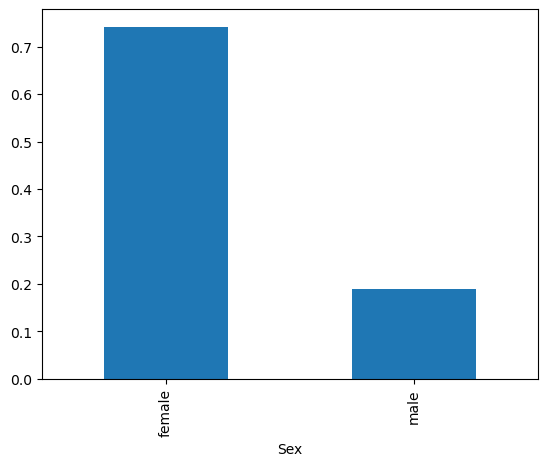

In [53]:
sex.plot(kind='bar')

<Axes: xlabel='Age'>

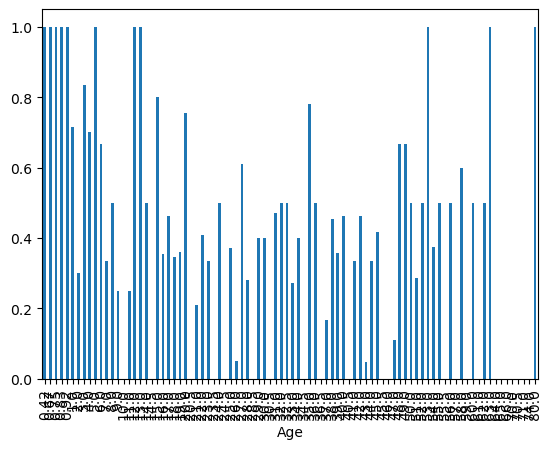

In [54]:
age=df2.groupby('Age')['Survived'].mean()
age
age.plot(kind='bar')

<Axes: xlabel='Pclass'>

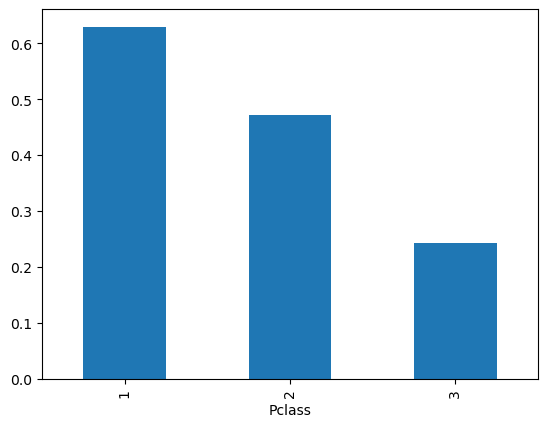

In [55]:
pclass=df2.groupby('Pclass')['Survived'].mean()
pclass.plot(kind='bar')

In [56]:
male=pd.get_dummies(df2['Sex'],drop_first=True,dtype=int)
male

,male
0,1
1,0
2,0
3,0
4,1
...,...
886,1
887,0
888,0
889,1


In [57]:
pd.get_dummies(df2['Sex'],dtype=int)

,female,male
0,0,1
1,1,0
2,1,0
3,1,0
4,0,1
...,...,...
886,0,1
887,1,0
888,1,0
889,0,1


In [58]:
pd.get_dummies(df2['Embarked'],drop_first=True,dtype=int)

,Q,S
0,0,1
1,0,0
2,0,1
3,0,1
4,0,1
...,...,...
886,0,1
887,0,1
888,0,1
889,0,0


In [59]:
x_temp=pd.concat([x,male],axis=1)
x_temp.head(2)


,Pclass,Age,SibSp,Parch,Fare,male
0,3,22.0,1,0,7.2500,1
1,1,38.0,1,0,71.2833,0


In [60]:
tmp=pd.concat([x,x],axis=0)
tmp.shape

(1782, 5)

In [62]:
df2.head(3)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [63]:
x_temp.head(3)

,Pclass,Age,SibSp,Parch,Fare,male
0,3,22.0,1,0,7.2500,1
1,1,38.0,1,0,71.2833,0
2,3,26.0,0,0,7.9250,0


In [66]:
for j in range(1,20):
    s1,s2,m=learn(x_temp,t,depth=j)
    s='深さ{}:訓練データの精度{}::テストデータの精度{}'
    print(s.format(j,s1,s2))

深さ1:訓練データの精度0.787::テストデータの精度0.788
深さ2:訓練データの精度0.792::テストデータの精度0.782
深さ3:訓練データの精度0.847::テストデータの精度0.81
深さ4:訓練データの精度0.854::テストデータの精度0.849
深さ5:訓練データの精度0.865::テストデータの精度0.86
深さ6:訓練データの精度0.876::テストデータの精度0.866
深さ7:訓練データの精度0.904::テストデータの精度0.866
深さ8:訓練データの精度0.912::テストデータの精度0.894
深さ9:訓練データの精度0.926::テストデータの精度0.899
深さ10:訓練データの精度0.948::テストデータの精度0.883
深さ11:訓練データの精度0.956::テストデータの精度0.832
深さ12:訓練データの精度0.972::テストデータの精度0.849
深さ13:訓練データの精度0.971::テストデータの精度0.855
深さ14:訓練データの精度0.979::テストデータの精度0.844
深さ15:訓練データの精度0.983::テストデータの精度0.844
深さ16:訓練データの精度0.983::テストデータの精度0.844
深さ17:訓練データの精度0.985::テストデータの精度0.844
深さ18:訓練データの精度0.986::テストデータの精度0.849
深さ19:訓練データの精度0.986::テストデータの精度0.849


In [69]:
x_new=x_temp.copy()
s1,s2,model=learn(x_new,t,depth=5)

import pickle
with open('Survived.pkl','wb')as f:
    pickle.dump(model,f)

In [70]:
model.feature_importances_

array([0.12084767, 0.25107251, 0.06754808, 0.00275855, 0.05145686,
       0.50631633])

In [71]:
pd.DataFrame(model.feature_importances_,index=x_new.columns)

,0
Pclass,0.120848
Age,0.251073
SibSp,0.067548
Parch,0.002759
Fare,0.051457
male,0.506316


In [72]:
display(pd.DataFrame(model.feature_importances_,index=x_new.columns))

,0
Pclass,0.120848
Age,0.251073
SibSp,0.067548
Parch,0.002759
Fare,0.051457
male,0.506316
